In [2]:
import pandas as pd
import numpy as np

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import keras

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. Número de embarazos.
# 2. Concentración de glucosa en plasma a 2 horas en una prueba oral de tolerancia a la glucosa.
# 3. Presión arterial diastólica (mm Hg).
# 4. Grosor del pliegue de la piel del tríceps (mm).
# 5. Insulina sérica de 2 horas (mu U/ml).
# 6. Índice de masa corporal.
# 7. Función del pedigrí de la diabetes.
# 8. Edad (años).
# 9. Clase, aparición de diabetes en un plazo de cinco años.

path = "./dataset/Pima_Indians_Diabetes_Database.csv"
# dataset = pd.read_csv(path, delimiter=",")
# dataset.head(10)

dataset = pd.read_csv(path, delimiter=",")
# Mostrar el DataFrame original
print("DataFrame original:")
print(dataset.head())
# dataset = dataset.sample(frac=1)
# dataset = dataset.to_numpy()
# np.size(dataset, 0)


DataFrame original:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
# Eliminar la primera fila del DataFrame original
dataset = dataset.iloc[1:].reset_index(drop=True)

print("\nDataFrame original sin la primera fila:")
print(dataset.head())


DataFrame original sin la primera fila:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1       85             66             29        0  26.6   
1            8      183             64              0        0  23.3   
2            1       89             66             23       94  28.1   
3            0      137             40             35      168  43.1   
4            5      116             74              0        0  25.6   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.351   31        0  
1                     0.672   32        1  
2                     0.167   21        0  
3                     2.288   33        1  
4                     0.201   30        0  


In [5]:
dataset = dataset.sample(frac=1)
dataset = dataset.to_numpy()
np.size(dataset, 0)

np.random.seed(7)

In [6]:
# Obtener el número de valores de entrenamiento, validacion, test a utilizar

numbers_val = round((np.size(dataset,0) * 20) / 100)

numbers_test = round((np.size(dataset,0) * 20) / 100)

numbers_train = np.size(dataset,0) - numbers_val - numbers_test

In [7]:
# Obtener el dataset para entrenamiento, validación, test
X_train = dataset[0:numbers_train,0:8]
Y_train = dataset[0:numbers_train,8]

X_val = dataset[numbers_train:(numbers_train+numbers_val), 0:8]
Y_val = dataset[numbers_train:(numbers_train+numbers_val), 8]

X_test = dataset[(numbers_train+numbers_val):np.size(dataset,0),0:8]
Y_test = dataset[(numbers_train+numbers_val):np.size(dataset,0),8]

print(X_train)
print(X_val)
print(X_test)

[[8.00e+00 1.26e+02 8.80e+01 ... 3.85e+01 3.49e-01 4.90e+01]
 [1.50e+01 1.36e+02 7.00e+01 ... 3.71e+01 1.53e-01 4.30e+01]
 [1.40e+01 1.75e+02 6.20e+01 ... 3.36e+01 2.12e-01 3.80e+01]
 ...
 [6.00e+00 8.00e+01 8.00e+01 ... 3.98e+01 1.77e-01 2.80e+01]
 [3.00e+00 1.74e+02 5.80e+01 ... 3.29e+01 5.93e-01 3.60e+01]
 [1.30e+01 1.45e+02 8.20e+01 ... 2.22e+01 2.45e-01 5.70e+01]]
[[  3.    100.     68.    ...  31.6     0.949  28.   ]
 [  0.    102.     64.    ...  40.6     0.496  21.   ]
 [  0.     97.     64.    ...  36.8     0.6    25.   ]
 ...
 [  1.    100.     74.    ...  19.5     0.149  28.   ]
 [  0.    137.     40.    ...  43.1     2.288  33.   ]
 [  4.     95.     60.    ...  35.4     0.284  28.   ]]
[[1.000e+00 8.100e+01 7.400e+01 ... 4.630e+01 1.096e+00 3.200e+01]
 [0.000e+00 1.090e+02 8.800e+01 ... 3.250e+01 8.550e-01 3.800e+01]
 [0.000e+00 1.370e+02 7.000e+01 ... 3.320e+01 1.700e-01 2.200e+01]
 ...
 [5.000e+00 4.400e+01 6.200e+01 ... 2.500e+01 5.870e-01 3.600e+01]
 [6.000e+00 1.050e+

In [8]:
# Crear Modelo con Keras

model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

/Users/vchibilisco/Documents/proyectos/facultad/ejemplos-IA/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Preparar modelo con optimizador, error y metrica
opt = Adam(learning_rate=0.01)

model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

In [ ]:
# Entrenar modelo

history = model.fit(X_train, Y_train, epochs=150, batch_size=10,validation_data=(X_val, Y_val))

Epoch 1/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5282 - loss: 1.4851 - val_accuracy: 0.6144 - val_loss: 0.6747
Epoch 2/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6787 - loss: 0.6583 - val_accuracy: 0.6209 - val_loss: 0.6658
Epoch 3/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.6274 - loss: 0.6605 - val_accuracy: 0.6209 - val_loss: 0.6647
Epoch 4/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - accuracy: 0.6401 - loss: 0.6538 - val_accuracy: 0.6209 - val_loss: 0.6661
Epoch 5/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.7012 - loss: 0.6172 - val_accuracy: 0.6209 - val_loss: 0.6676
Epoch 6/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6771 - loss: 0.6289 - val_accuracy: 0.6144 - val_loss: 0.6736
Epoch 7/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - accuracy: 0.6859 - loss: 0.6222 - val_accuracy: 0.6144 - val_loss: 0.6723
Epoch 8/150
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - accuracy: 0.6898 - loss: 0.6183 - val_accuracy: 

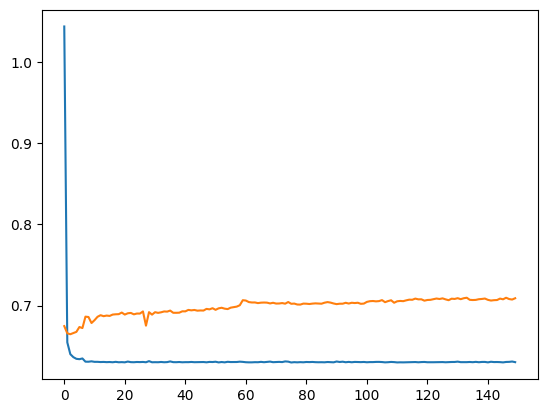

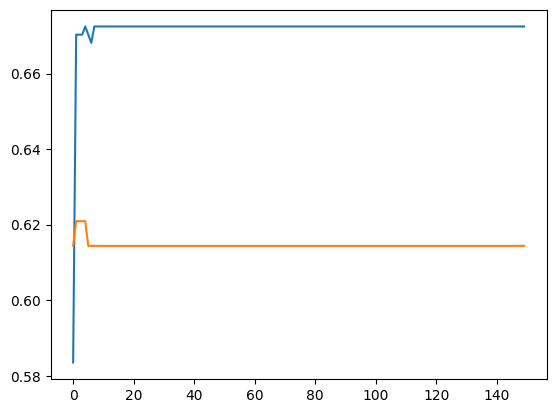

In [11]:
plt.plot(range(len(history.history['loss'])), history.history['loss'])
plt.plot(range(len(history.history['val_loss'])), history.history['val_loss'])


plt.show()

plt.plot(range(len(history.history['accuracy'])), history.history['accuracy'])
plt.plot(range(len(history.history['val_accuracy'])), history.history['val_accuracy'])

plt.show()


In [ ]:
class TrainingPlot(keras.callbacks.Callback):
    def __init__(self, clear_figure=False):
        super().__init__()
        self.epochs = []
        self.history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
        self.clear_figure = clear_figure
        
        if self.clear_figure:
            plt.ion()  # Modo interactivo

    def on_epoch_end(self, epoch, logs=None):
        self.epochs.append(epoch + 1)
        self.history['loss'].append(logs.get('loss'))
        self.history['accuracy'].append(logs.get('accuracy'))
        self.history['val_loss'].append(logs.get('val_loss'))
        self.history['val_accuracy'].append(logs.get('val_accuracy'))

        if (epoch + 1) % 100 == 0:
            self.plot_metrics(epoch)
            self.print_metrics()

    def plot_metrics(self, epoch):
        if self.clear_figure:
            plt.close()  # Cierra la figura anterior si está abierta
        
        epochs_range = self.epochs

        fig, axs = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plotear la pérdida
        axs[0].plot(epochs_range, self.history['loss'], label='Training Loss')
        axs[0].plot(epochs_range, self.history['val_loss'], label='Validation Loss')
        axs[0].set_xlabel('Epoch')
        axs[0].set_ylabel('Loss')
        axs[0].set_title('Training and Validation Loss')
        axs[0].legend()

        # Plotear la precisión
        axs[1].plot(epochs_range, self.history['accuracy'], label='Training Accuracy')
        axs[1].plot(epochs_range, self.history['val_accuracy'], label='Validation Accuracy')
        axs[1].set_xlabel('Epoch')
        axs[1].set_ylabel('Accuracy')
        axs[1].set_title('Training and Validation Accuracy')
        axs[1].legend()

        fig.suptitle(f'Epoch {epoch + 1}')
        plt.show()
        plt.pause(0.001)  # Pausa breve para actualizar la gráfica

    def print_metrics(self):
        print(f"Epoch {self.epochs[-1]} - Train Loss: {self.history['loss'][-1]}")
        print(f"Epoch {self.epochs[-1]} - Validation Loss: {self.history['val_loss'][-1]}")
        print("===================================")
        print(f"Epoch {self.epochs[-1]} - Train Accuracy: {self.history['accuracy'][-1]}")
        print(f"Epoch {self.epochs[-1]} - Validation Accuracy: {self.history['val_accuracy'][-1]}")

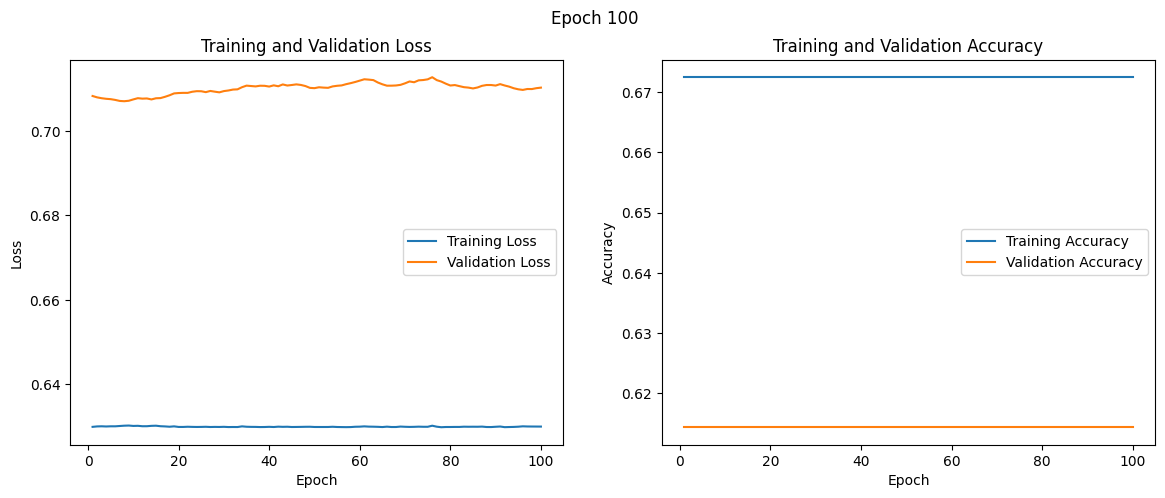

Epoch 100 - Train Loss: 0.6299582719802856
Epoch 100 - Validation Loss: 0.7102274894714355
Epoch 100 - Train Accuracy: 0.6724511981010437
Epoch 100 - Validation Accuracy: 0.6143791079521179


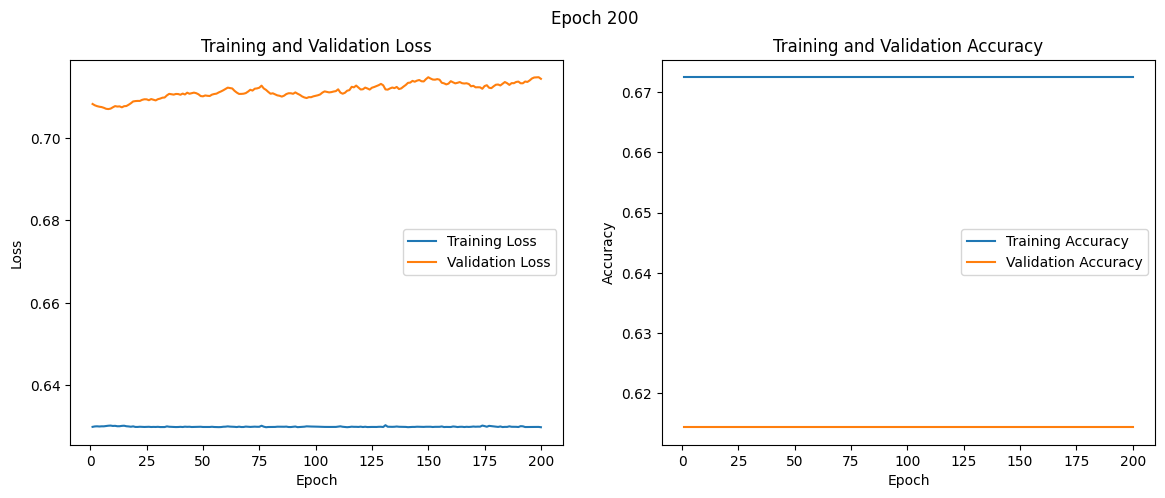

Epoch 200 - Train Loss: 0.6298040747642517
Epoch 200 - Validation Loss: 0.7143505215644836
Epoch 200 - Train Accuracy: 0.6724511981010437
Epoch 200 - Validation Accuracy: 0.6143791079521179


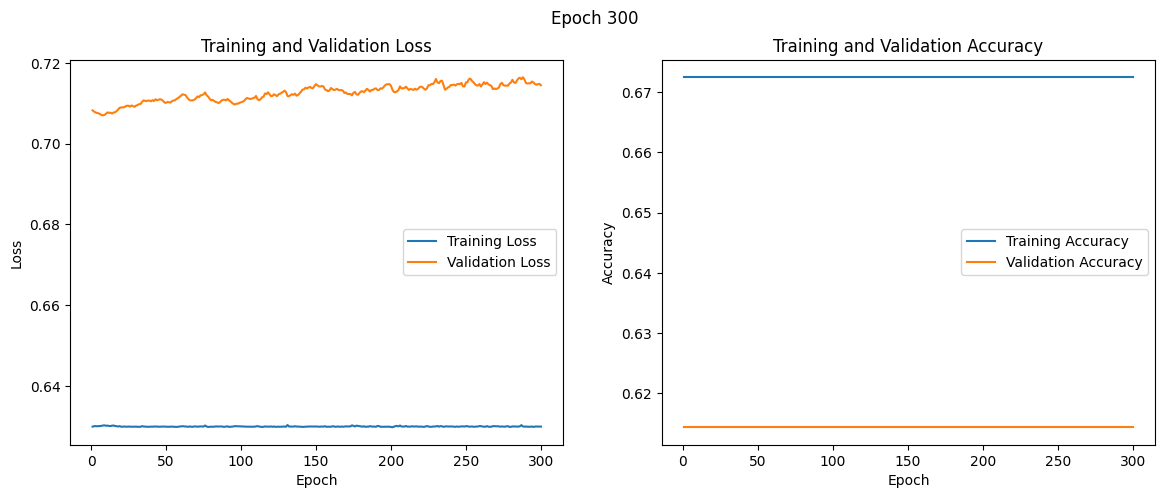

Epoch 300 - Train Loss: 0.6298947334289551
Epoch 300 - Validation Loss: 0.7144590616226196
Epoch 300 - Train Accuracy: 0.6724511981010437
Epoch 300 - Validation Accuracy: 0.6143791079521179


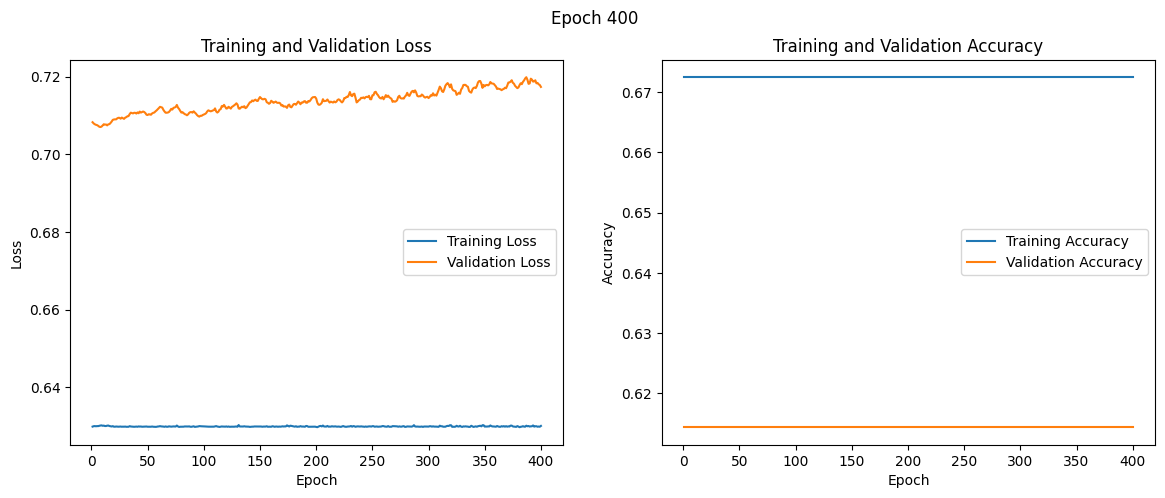

Epoch 400 - Train Loss: 0.6300718188285828
Epoch 400 - Validation Loss: 0.7173351645469666
Epoch 400 - Train Accuracy: 0.6724511981010437
Epoch 400 - Validation Accuracy: 0.6143791079521179


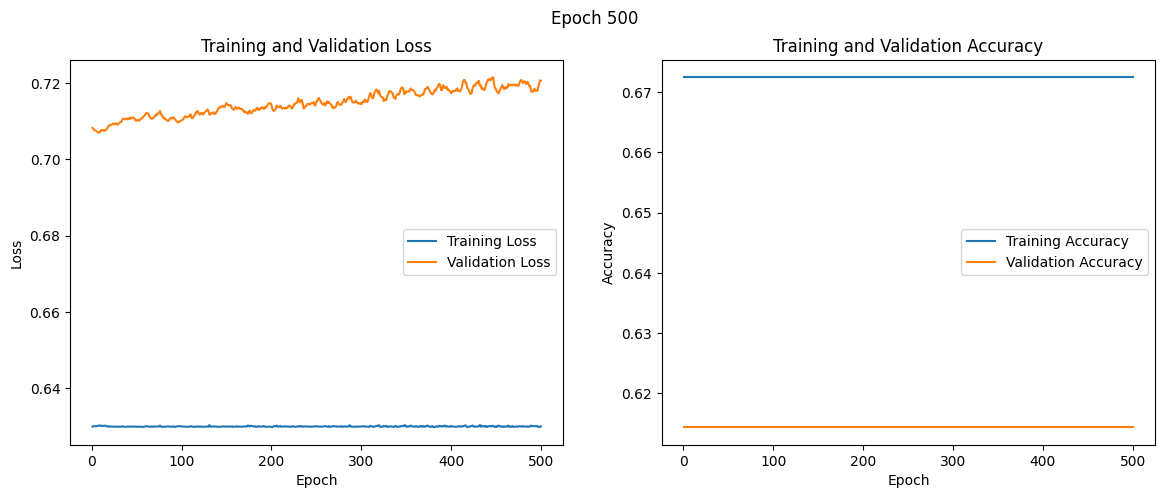

Epoch 500 - Train Loss: 0.6299325227737427
Epoch 500 - Validation Loss: 0.7206514477729797
Epoch 500 - Train Accuracy: 0.6724511981010437
Epoch 500 - Validation Accuracy: 0.6143791079521179


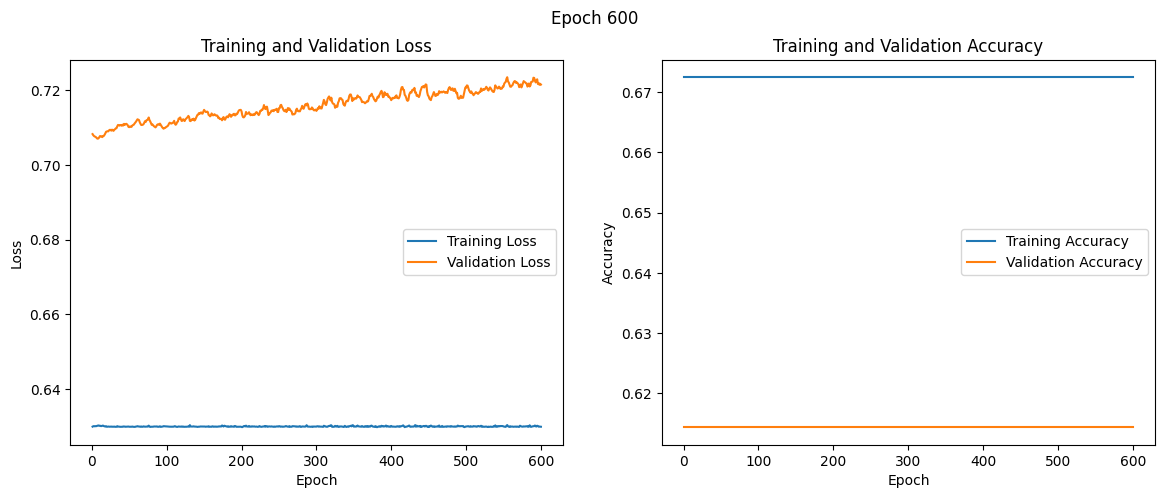

Epoch 600 - Train Loss: 0.6298620700836182
Epoch 600 - Validation Loss: 0.7215062379837036
Epoch 600 - Train Accuracy: 0.6724511981010437
Epoch 600 - Validation Accuracy: 0.6143791079521179


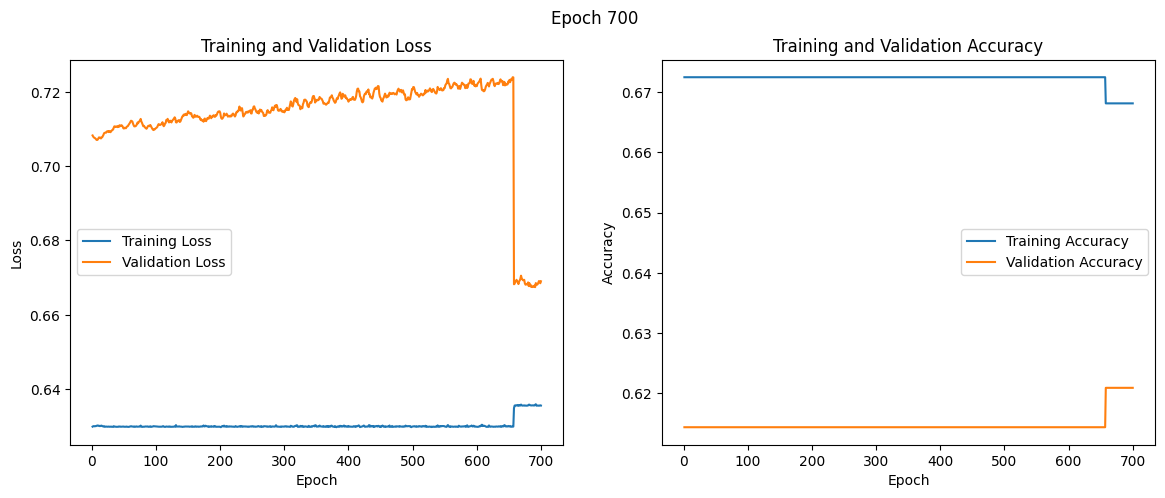

Epoch 700 - Train Loss: 0.635567843914032
Epoch 700 - Validation Loss: 0.6690025925636292
Epoch 700 - Train Accuracy: 0.6681128144264221
Epoch 700 - Validation Accuracy: 0.6209150552749634


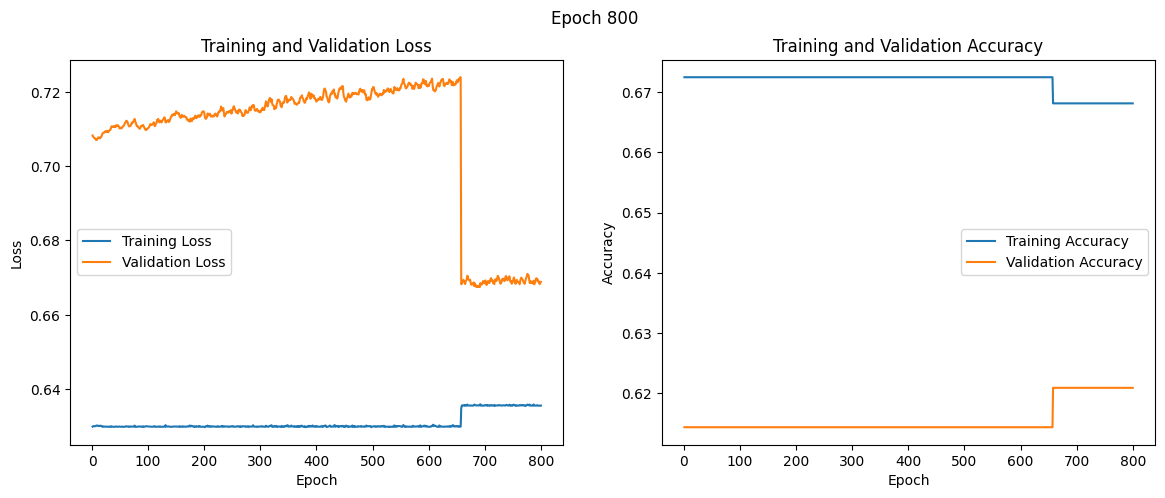

Epoch 800 - Train Loss: 0.6355577111244202
Epoch 800 - Validation Loss: 0.6688346862792969
Epoch 800 - Train Accuracy: 0.6681128144264221
Epoch 800 - Validation Accuracy: 0.6209150552749634


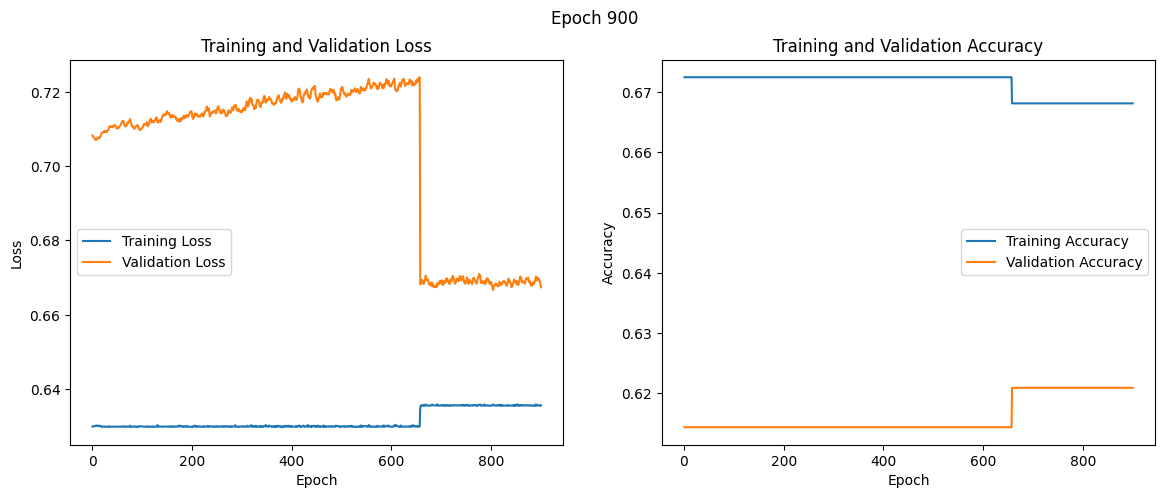

Epoch 900 - Train Loss: 0.6356034278869629
Epoch 900 - Validation Loss: 0.6673779487609863
Epoch 900 - Train Accuracy: 0.6681128144264221
Epoch 900 - Validation Accuracy: 0.6209150552749634


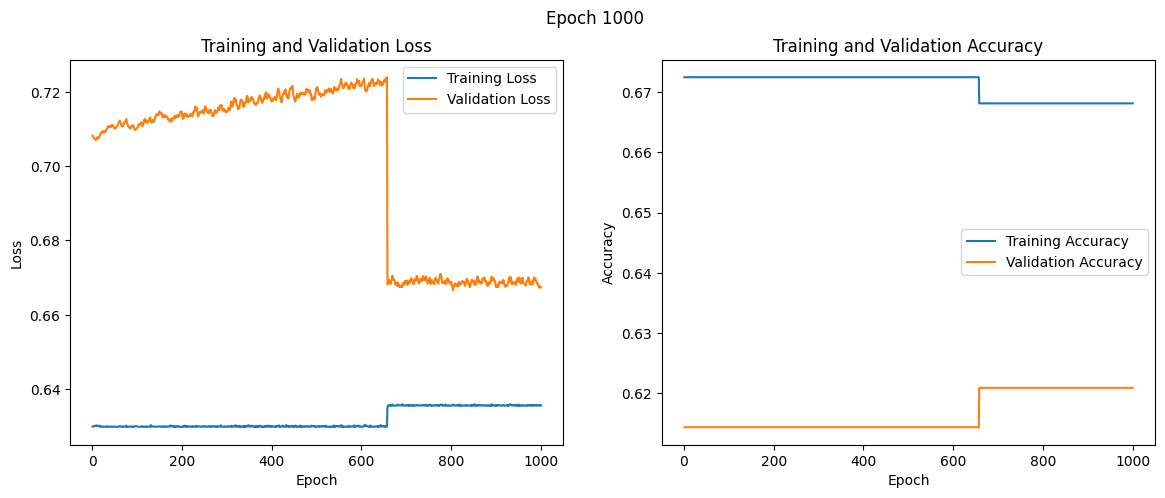

Epoch 1000 - Train Loss: 0.6355963945388794
Epoch 1000 - Validation Loss: 0.6673287153244019
Epoch 1000 - Train Accuracy: 0.6681128144264221
Epoch 1000 - Validation Accuracy: 0.6209150552749634


In [13]:
# Crear la instancia de la callback
custom_callback = TrainingPlot(clear_figure=True)

model.fit(X_train, Y_train, epochs=1000, validation_data=(X_val, Y_val), batch_size=50, verbose=0, callbacks=[custom_callback])

In [14]:
# evalua el modelo
scores = model.evaluate(X_test, Y_test)
print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6024 - loss: 0.6798

compile_metrics: 63.40%


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


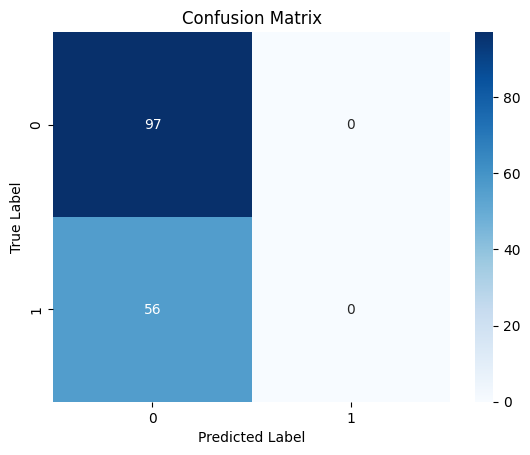

In [15]:
y_pred_proba = model.predict(X_test)

y_pred = np.argmax(y_pred_proba, axis=1) 

conf_mat = confusion_matrix(Y_test, y_pred)

# Visualización de la matriz de confusión
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()